<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Introduction to Machine Learning
</font>
<hr/>
<font color="#800080" size=5>
Phase 1
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>
<font face="Times New Roman" size=4>
</font>
<hr>
<font color='red'  size=4>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @ZahraSorkhei
</font>
<br>
<hr>
</div></font>

# GMM and OOD Detection

In this notebook, you will implement a Gaussian Mixture Model (GMM) from scratch using the EM algorithm and use it for Out-of-Distribution (OOD) detection. We will start with 2D data and later extend to 3D.


## 1. Multivariate Gaussian PDF

First, we define a helper function to compute the multivariate Gaussian probability density function.

Complete the function below:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def gaussian_pdf(x, mean, cov):
    x = np.array(x)
    mean = np.array(mean)
    cov = np.array(cov)
    # TODO: Compute the dimension of x

    if x.ndim == 1:
        x = x[np.newaxis, :] # Convert to (1, d)
    d = x.shape[1]
    # TODO

    # TODO: Compute the difference between x and mean
    # Broadcasting mean: (N, d) - (d,)
    diff = x - mean

    # TODO: Compute inverse and determinant of covariance
    cov_reg = cov + np.eye(d) * 1e-6
    inv_cov = np.linalg.inv(cov_reg)
    det_cov = np.linalg.det(cov_reg)


    # TODO: Compute normalization constant
    norm_const = 1.0 / ((2 * np.pi) ** (d / 2) * np.sqrt(det_cov))

    # TODO: Compute exponent term
    exponent = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
    exp_term = np.exp(exponent)

    return norm_const * exp_term


## 2. Implement GMM Class with EM

We will implement a GMM class with the EM algorithm.


In [ ]:
class GMM:
    def __init__(self, n_components, max_iters=100, tol=1e-3):
        self.K = n_components
        self.max_iters = max_iters
        self.tol = tol

    def initialize(self, X):
        n, d = X.shape
        rng = np.random.default_rng()

        # TODO: Initialize means randomly from X
        random_indices = rng.choice(n, size=self.K, replace=False)
        self.means = X[random_indices]

        # TODO: Initialize covariance matrices
        self.covs = np.array([np.eye(d) for _ in range(self.K)])

        # TODO: Initialize mixture weights
        self.weights = np.ones(self.K) / self.K

    def e_step(self, X):
        n = X.shape[0]
        gamma = np.zeros((n, self.K))

        # TODO: Compute responsibilities
        for k in range(self.K):
            gamma[:, k] = self.weights[k] * gaussian_pdf(X, self.means[k], self.covs[k])
            # TODO
            pass

        # TODO: Normalize responsibilities
        sum_gamma = np.sum(gamma, axis=1, keepdims=True)
        gamma = gamma / (sum_gamma + 1e-10)
        return gamma

    def m_step(self, X, gamma):
        n, d = X.shape
        # TODO: Sum responsibilities for each component
        Nk = np.sum(gamma, axis=0) # Shape: (K,)

        # TODO: Update weights
        self.weights = Nk / n

        # TODO: Update means
        # Mean_k = (1/N_k) * sum(gamma_ik * x_i)
        # Using matrix multiplication: (K, N) @ (N, d) -> (K, d)
        self.means = (gamma.T @ X) / Nk[:, np.newaxis]

        # TODO: Update covariances
        for k in range(self.K):
            diff = X - self.means[k] # (N, d)
            # Cov_k = (1/N_k) * sum(gamma_ik * (x_i-mu_k)(x_i-mu_k)^T)
            # Weighting the difference
            weighted_diff = gamma[:, k][:, np.newaxis] * diff
            self.covs[k] = (weighted_diff.T @ diff) / Nk[k]

            # Regularization to keep matrix pd
            self.covs[k] += np.eye(d) * 1e-6
    def log_likelihood(self, X):
        # TODO: Compute log-likelihood for each sample
        # L = sum_i log( sum_k pi_k * N(x_i | ...) )
        n = X.shape[0]
        likelihoods = np.zeros((n, self.K))
        for k in range(self.K):
            likelihoods[:, k] = self.weights[k] * gaussian_pdf(X, self.means[k], self.covs[k])

        total_likelihood = np.sum(likelihoods, axis=1)

        # Return mean log-likelihood
        return np.mean(np.log(total_likelihood + 1e-10))

    def score_samples(self, X):
        """Helper for OOD detection: returns log-likelihood per sample"""
        n = X.shape[0]
        likelihoods = np.zeros((n, self.K))
        for k in range(self.K):
            likelihoods[:, k] = self.weights[k] * gaussian_pdf(X, self.means[k], self.covs[k])
        return np.log(np.sum(likelihoods, axis=1) + 1e-10)

    def fit(self, X):
        self.initialize(X)
        prev_ll = None

        for i in range(self.max_iters):
            # TODO: E-step
            gamma = self.e_step(X)

            # TODO: M-step
            self.m_step(X, gamma)
            # TODO

            # TODO: Compute mean log-likelihood
            ll = self.log_likelihood(X)
            if i % 10 == 0:
                print(f"Iteration {i}: Log-Likelihood = {ll:.4f}")

            # Check for convergence
            if prev_ll is not None and abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll

        print(f"EM converged in {i+1} iterations")


## 3. Generate Toy 2D Data

Generate a 2D dataset with two Gaussian clusters (ID data) and some uniform OOD points.


In [ ]:
np.random.seed(0)

# ID data (mixture of Gaussians)
N = 600
X1 = np.random.multivariate_normal([0, 0], [[0.8, 0.2], [0.2, 0.6]], N // 2)
X2 = np.random.multivariate_normal([3, 3], [[0.6, -0.1], [-0.1, 0.6]], N // 2)
X_id = np.vstack([X1, X2])

# OOD data (far away)
X_ood = np.random.uniform(low=-6, high=6, size=(200, 2))


## 4. Train GMM on ID Data

Use your implemented GMM class to fit the ID dataset.


In [ ]:
# TODO: Initialize GMM with 2 components
gmm = GMM(n_components=2, max_iters=50, tol=1e-4)

# TODO: Fit GMM
gmm.fit(X_id)
# TODO


Iteration 0: Log-Likelihood = -3.3456
Iteration 10: Log-Likelihood = -3.0079
EM converged in 14 iterations


## 5. OOD Detection

Compute log-likelihoods for ID and OOD points, and detect OOD points using a threshold.


In [ ]:
# TODO: Compute log-likelihoods for ID and OOD data
ll_id = gmm.score_samples(X_id)
ll_ood = gmm.score_samples(X_ood)

# TODO: Set threshold
threshold = np.percentile(ll_id, 5)
print(f"Likelihood Threshold: {threshold:.4f}")

# TODO: Make predictions
# If log_likelihood < threshold => OOD (Class 1), else ID (Class 0)
# Here we just label them for visualization: ID=0, OOD=1
pred_id = (ll_id < threshold).astype(int)   # Should be mostly 0
pred_ood = (ll_ood < threshold).astype(int) # Should be mostly 1

print(f"Accuracy on ID (True Negative Rate): {100 * np.mean(pred_id == 0):.2f}%")
print(f"Accuracy on OOD (True Positive Rate): {100 * np.mean(pred_ood == 1):.2f}%")


Likelihood Threshold: -4.8876
Accuracy on ID (True Negative Rate): 95.00%
Accuracy on OOD (True Positive Rate): 83.00%


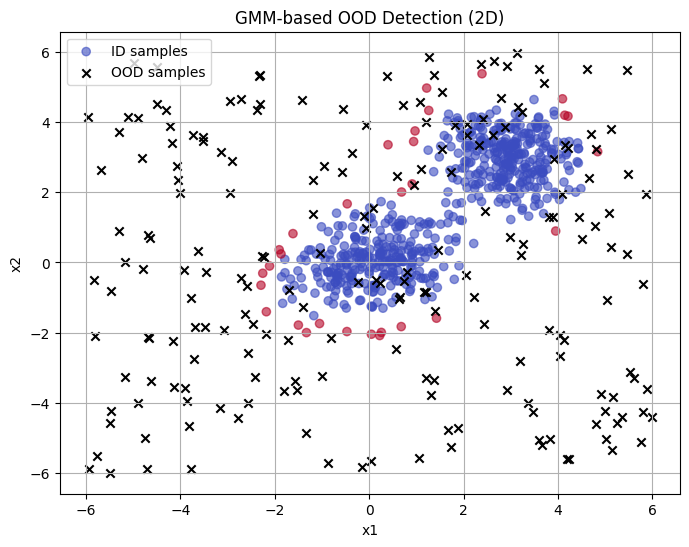

In [ ]:
import matplotlib.pyplot as plt
# =========================
# Visualization
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(X_id[:, 0], X_id[:, 1],
            c=pred_id, cmap="coolwarm", alpha=0.6, label="ID samples")
plt.scatter(X_ood[:, 0], X_ood[:, 1],
            c="black", marker="x", label="OOD samples")
plt.legend()
plt.title("GMM-based OOD Detection (2D)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

# GMM Image Segmentation

In this notebook, you will apply Gaussian Mixture Models (GMM) with EM algorithm to perform clustering-based segmentation on color images. You will work with 3-channel images (RGB).

## 1. Gaussian PDF Function

Complete the multivariate Gaussian PDF function. This function will be used in the EM algorithm.


In [1]:
import numpy as np

def gaussian_pdf(x, mean, cov):
    # Ensure inputs are numpy arrays
    x = np.array(x)
    mean = np.array(mean)
    cov = np.array(cov)

    # TODO: Compute the dimension of x
    # If x is (N, d), d is shape[1]. If (d,), d is shape[0].
    d = mean.shape[0]

    # TODO: Compute the difference between x and mean
    diff = x - mean

    # TODO: Compute inverse and determinant of covariance
    # Adding epsilon for numerical stability is crucial
    cov_reg = cov + np.eye(d) * 1e-6
    inv_cov = np.linalg.inv(cov_reg)
    det_cov = np.linalg.det(cov_reg)

    # TODO: Compute normalization constant
    norm_const = 1.0 / ((2 * np.pi) ** (d / 2) * np.sqrt(det_cov))

    # TODO: Compute exponent term
    # Formula: -0.5 * (x - mu)^T * Sigma^-1 * (x - mu)
    # Using einsum for efficient batch computation if x is (N, d)
    if x.ndim == 2:
        exponent = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
    else:
        exponent = -0.5 * (diff.T @ inv_cov @ diff)

    # TODO: Compute final PDF value
    exp_term = np.exp(exponent)

    return norm_const * exp_term

## 2. Implement GMM Class with EM

Fill in the missing parts for the GMM class.


In [ ]:
import numpy as np

class GMM:
    def __init__(self, n_components, max_iters=100, tol=1e-3):
        self.K = n_components
        self.max_iters = max_iters
        self.tol = tol

    def initialize(self, X):
        n, d = X.shape
        rng = np.random.default_rng(42)


        min_val = np.min(X, axis=0)
        max_val = np.max(X, axis=0)

        # Create K random means distributed uniformly within the data range
        self.means = rng.uniform(low=min_val, high=max_val, size=(self.K, d))

        # Initialize covariance matrices (Identity matrices)
        self.covs = np.array([np.eye(d) for _ in range(self.K)])

        # Initialize mixture weights (Uniform)
        self.weights = np.ones(self.K) / self.K

    def e_step(self, X):
        n = X.shape[0]
        gamma = np.zeros((n, self.K))

        # Compute responsibilities
        for k in range(self.K):
            gamma[:, k] = self.weights[k] * gaussian_pdf(X, self.means[k], self.covs[k])

        # Normalize responsibilities
        sum_gamma = np.sum(gamma, axis=1, keepdims=True)
        gamma = gamma / (sum_gamma + 1e-10) # Avoid division by zero
        return gamma

    def m_step(self, X, gamma):
        n, d = X.shape

        # Sum responsibilities (N_k)
        Nk = np.sum(gamma, axis=0)

        # Update weights
        self.weights = Nk / n

        # Update means
        # Reshape Nk for broadcasting: (K, 1)
        self.means = (gamma.T @ X) / (Nk[:, np.newaxis] + 1e-10)

        # Update covariances
        for k in range(self.K):
            diff = X - self.means[k]
            # Weighted covariance: sum(gamma * diff * diff^T)
            weighted_diff = gamma[:, k][:, np.newaxis] * diff
            self.covs[k] = (weighted_diff.T @ diff) / (Nk[k] + 1e-10)

            # Regularization to prevent singular matrices
            self.covs[k] += np.eye(d) * 1e-6

    def log_likelihood(self, X):
        n = X.shape[0]
        likelihoods = np.zeros((n, self.K))
        for k in range(self.K):
            likelihoods[:, k] = self.weights[k] * gaussian_pdf(X, self.means[k], self.covs[k])

        total_likelihood = np.sum(likelihoods, axis=1)
        return np.mean(np.log(total_likelihood + 1e-10))

    def fit(self, X):
        self.initialize(X)
        prev_ll = -np.inf

        for i in range(self.max_iters):
            gamma = self.e_step(X)
            self.m_step(X, gamma)
            ll = self.log_likelihood(X)

            if prev_ll is not None and abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll

    def predict(self, X):
        gamma = self.e_step(X)
        return np.argmax(gamma, axis=1)

## 3. Segment Image Function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
import cv2
from skimage import data
from matplotlib.patches import Patch

def segment_image(image, K, title):
      """
      Segment a color image using GMM clustering.
      """
      if image.dtype != np.uint8:
          if image.max() <= 1.0:
              image = (image * 255).astype(np.uint8)
          else:
              image = image.astype(np.uint8)

      # Resize the image to 256x256 to speed up training
      image = cv2.resize(image, (256, 256))

      # If grayscale, convert to 3-channel RGB
      if image.ndim == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

      H, W, _ = image.shape

      # Reshape image to N x 3 for GMM
      X = image.reshape(-1, 3)
      X = X.astype(np.float32) / 255.0

      # Initialize GMM and fit to pixel data
      print(f"Training GMM (K={K}) on image: {title}...")

      # Uses the GMM class 
      gmm = GMM(n_components=K, max_iters=30, tol=1e-3)
      gmm.fit(X)

      # Predict cluster labels and reshape
      labels = gmm.predict(X)
      label_map = labels.reshape(H, W)

      # Visualization
      cmap = plt.get_cmap("tab10", K)
      legend_elements = [
          Patch(facecolor=cmap(k), edgecolor='k', label=f'Cluster {k}')
          for k in range(K)]

      plt.figure(figsize=(10, 4))

      plt.subplot(1, 2, 1)
      plt.imshow(image)
      plt.title(f"Original – {title}")
      plt.axis("off")

      plt.subplot(1, 2, 2)
      plt.imshow(label_map, cmap=cmap)
      plt.title("GMM Segmentation (Labels)")
      plt.axis("off")
      plt.legend(handles=legend_elements,
                bbox_to_anchor=(1.05, 1),
                loc="upper left",
                borderaxespad=0.)

      plt.tight_layout()
      plt.show()

Training GMM (K=4) on image: Medical – Abdominal CT-like...


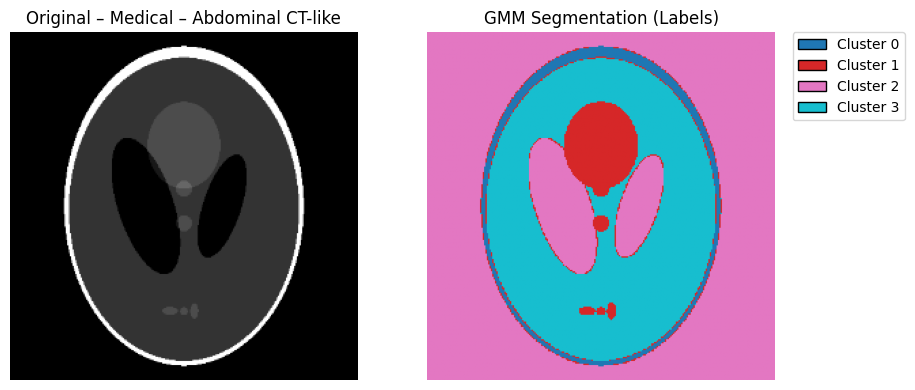

Training GMM (K=3) on image: Medical – Retina (Natural)...


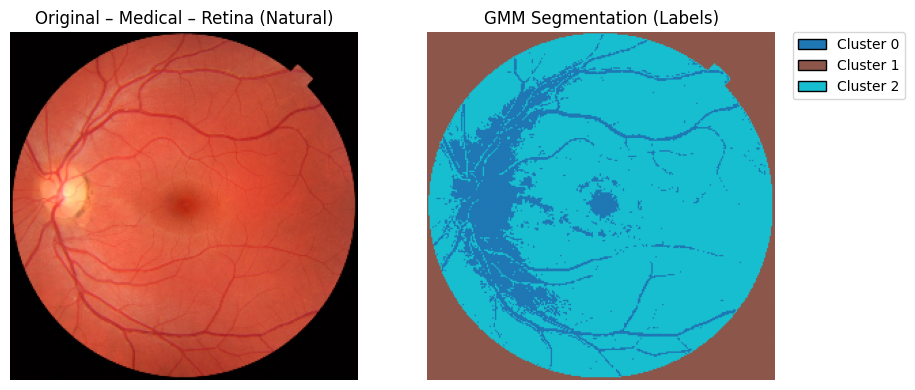

Training GMM (K=4) on image: Natural Scene...


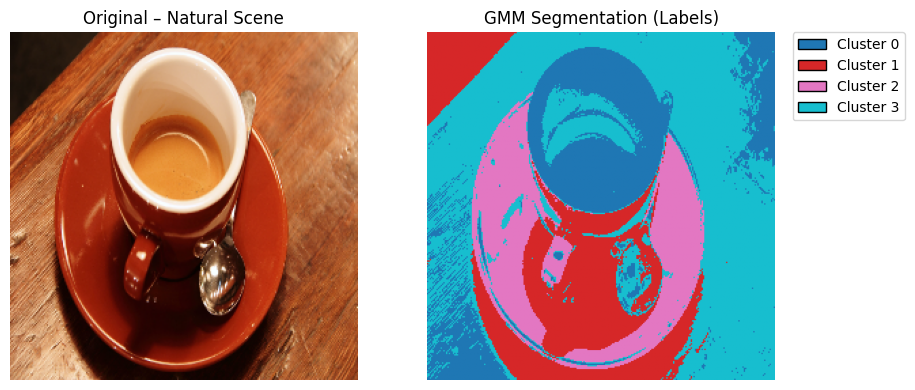

Training GMM (K=4) on image: Outdoor / Driving-like Scene...


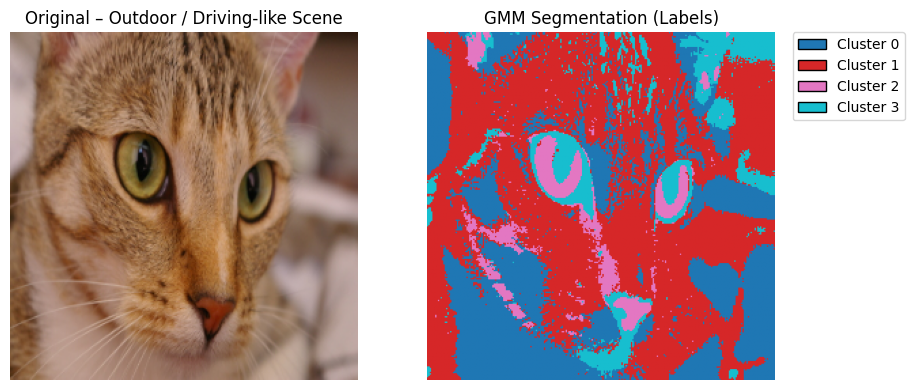

Training GMM (K=4) on image: Natural Landscape...


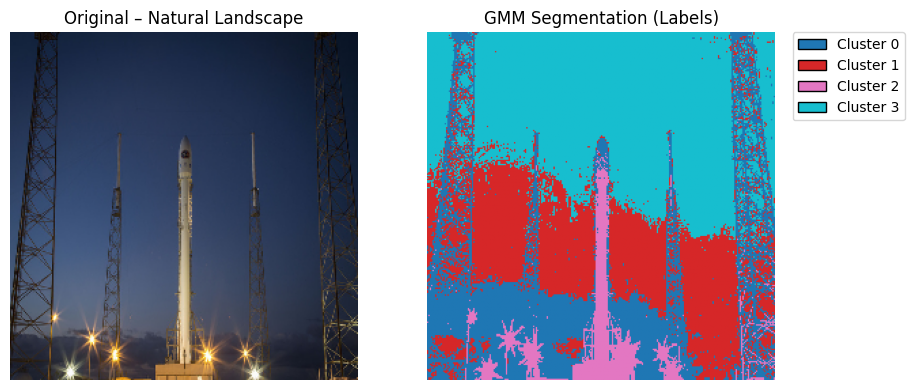

In [13]:
# =========================
# Run experiments
# =========================

segment_image(data.shepp_logan_phantom(), 4, "Medical – Abdominal CT-like")
segment_image(data.retina(),  K=3, title="Medical – Retina (Natural)")
segment_image(data.coffee(), 4, "Natural Scene")
segment_image(data.chelsea(), 4, "Outdoor / Driving-like Scene")
segment_image(data.rocket(), 4, "Natural Landscape")